Polynomial Coefficients:  [2.09218103 1.58837751 0.60606342]


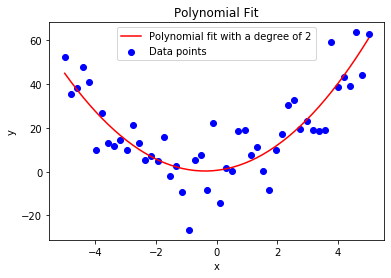

In [26]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)
x = np.linspace(-5, 5, 50)
y = 2 * x**2 + 3 * x + np.random.randn(50) * 10

degree = 2
coefficients = np.polyfit(x, y, degree)

print("Polynomial Coefficients: ", coefficients)

polynomial = np.poly1d(coefficients)
y_pred = polynomial(x)

plt.scatter(x, y, color='b', label='Data points')
plt.plot(x, y_pred, color='r', label=f'Polynomial fit with a degree of {degree}')
plt.title('Polynomial Fit')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()

Linear Least Squares
Slope: 1.5883775070098138
Intercept: 18.752531498641176
MSE: 372.0051625579934
R^2: 0.05555558712253694

Cubic Polynomial Fit
Coefficients: [-0.06652428  2.09218103  2.62641665  0.60606342]
MSE: 107.11173673839265
R^2: 0.7280653832313249

Cubic polynomial fits better


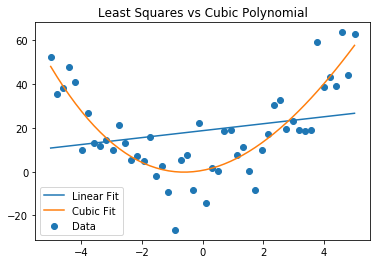

In [27]:
def evaluate(y, y_pred):
    mse = np.mean((y - y_pred)**2)

    ss_total = np.sum((y - np.mean(y))**2)
    ss_residual = np.sum((y - y_pred)**2)

    r2 = 1 - ss_residual / ss_total
    return mse, r2


# Linear Least Squares
A = np.vstack([x, np.ones(len(x))]).T
m, b = np.linalg.lstsq(A, y, rcond=None)[0]

y_linear = m * x + b
mse_linear, r2_linear = evaluate(y, y_linear)

print("Linear Least Squares")
print("Slope:", m)
print("Intercept:", b)
print("MSE:", mse_linear)
print("R^2:", r2_linear)


# Cubic Polynomial Fit
degree = 3
coeff_poly = np.polyfit(x, y, degree)

poly = np.poly1d(coeff_poly)
y_poly = poly(x)

mse_poly, r2_poly = evaluate(y, y_poly)

print("\nCubic Polynomial Fit")
print("Coefficients:", coeff_poly)
print("MSE:", mse_poly)
print("R^2:", r2_poly)


# Decide which is better
if mse_poly < mse_linear and r2_poly > r2_linear:
    print("\nCubic polynomial fits better")
else:
    print("\nLinear least squares fits better")


# Plot both
plt.scatter(x, y, label="Data")
plt.plot(x, y_linear, label="Linear Fit")
plt.plot(x, y_poly, label="Cubic Fit")
plt.legend()
plt.title("Least Squares vs Cubic Polynomial")
plt.show()

Increasing Polynomial Degree
Degree: 3
MSE: 107.11173673839265
R^2: 0.7280653832313249



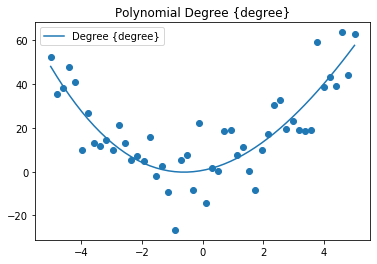

Degree: 4
MSE: 106.64598775650336
R^2: 0.7292478238746859



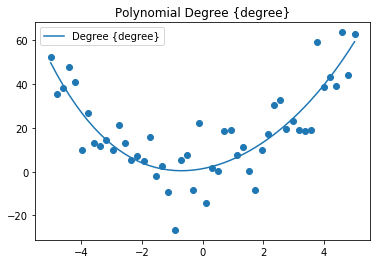

Degree: 5
MSE: 106.56131173306981
R^2: 0.7294627988408573



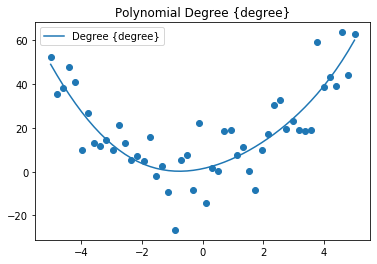

Degree: 6
MSE: 106.50809238892032
R^2: 0.7295979117836278



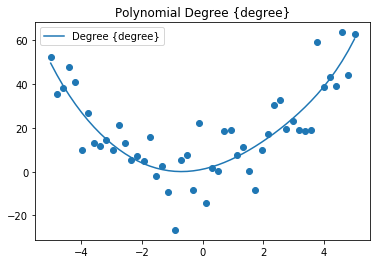

Degree: 7
MSE: 105.98312121449808
R^2: 0.7309307053642209



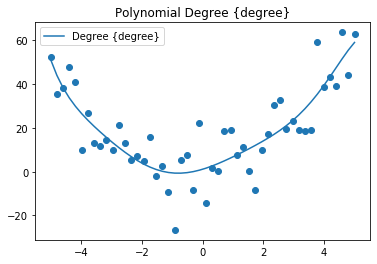

In [23]:
#Overfitting the data
def evaluate(y, y_pred):
    mse = np.mean((y - y_pred)**2)

    ss_total = np.sum((y - np.mean(y))**2)
    ss_residual = np.sum((y - y_pred)**2)

    r2 = 1 - ss_residual / ss_total
    return mse, r2


print("Increasing Polynomial Degree")

for degree in range(3, 8):

    coeff = np.polyfit(x, y, degree)
    poly = np.poly1d(coeff)

    y_pred = poly(x)

    mse, r2 = evaluate(y, y_pred)

    print("Degree:", degree)
    print("MSE:", mse)
    print("R^2:", r2)
    print()

    plt.scatter(x, y)
    plt.plot(x, y_pred, label=f"Degree {degree}")
    plt.legend()
    plt.title(f"Polynomial Degree {degree}")
    plt.show()

Decreasing Polynomial Degree
Degree: 3
MSE: 107.11173673839265
R^2: 0.7280653832313249



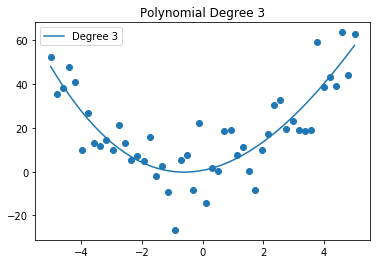

Degree: 2
MSE: 108.8859685268728
R^2: 0.7235609745068399



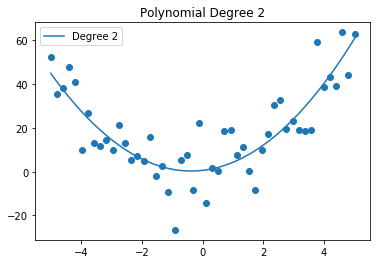

Degree: 1
MSE: 372.0051625579934
R^2: 0.05555558712253694



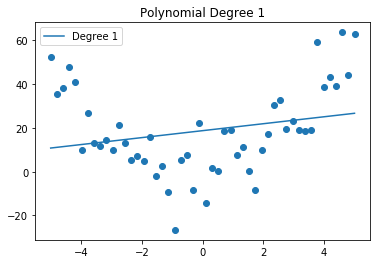

In [28]:
#Underfitting the data
def evaluate(y, y_pred):
    mse = np.mean((y - y_pred)**2)

    ss_total = np.sum((y - np.mean(y))**2)
    ss_residual = np.sum((y - y_pred)**2)

    r2 = 1 - ss_residual / ss_total
    return mse, r2


print("Decreasing Polynomial Degree")

for degree in range(3, 0, -1):

    coeff = np.polyfit(x, y, degree)
    poly = np.poly1d(coeff)

    y_pred = poly(x)

    mse, r2 = evaluate(y, y_pred)

    print("Degree:", degree)
    print("MSE:", mse)
    print("R^2:", r2)
    print()

    plt.scatter(x, y)
    plt.plot(x, y_pred, label=f"Degree {degree}")
    plt.legend()
    plt.title(f"Polynomial Degree {degree}")
    plt.show()

Vandermonde Polynomial Fit
Coefficients: [ 0.60606342  2.62641665  2.09218103 -0.06652428]
MSE: 107.11173673839262
R^2: 0.7280653832313249


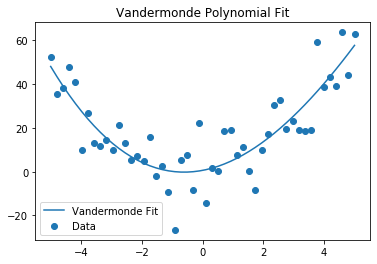

In [29]:
#The Vandermonde Polynomial Fit
def evaluate(y, y_pred):

    mse = np.mean((y - y_pred)**2)

    ss_total = np.sum((y - np.mean(y))**2)
    ss_residual = np.sum((y - y_pred)**2)

    r2 = 1 - ss_residual / ss_total

    return mse, r2


degree = 3

# Build Vandermonde matrix
V = np.vander(x, degree + 1, increasing=True)

# V.T * V
VT_V = np.dot(V.T, V)

# V.T * y
VT_y = np.dot(V.T, y)

# Solve for coefficients
coefficients = np.linalg.solve(VT_V, VT_y)

# Build polynomial (reverse order for poly1d)
polynomial = np.poly1d(coefficients[::-1])

y_pred = polynomial(x)

mse, r2 = evaluate(y, y_pred)

print("Vandermonde Polynomial Fit")
print("Coefficients:", coefficients)
print("MSE:", mse)
print("R^2:", r2)

plt.scatter(x, y, label="Data")
plt.plot(x, y_pred, label="Vandermonde Fit")
plt.legend()
plt.title("Vandermonde Polynomial Fit")
plt.show()